# Rescan check: same space, different scans

ScanNet ids look like `sceneXXXX_YY`: `XXXX` is the space, `YY` the scan index, so
`scene0000_00` and `scene0000_01` are two scans of the same room. 3RScan has the same
idea (a reference scan plus rescans of one environment), but its ids are UUIDs, so the
grouping comes from the official `3RScan.json` metadata.

This notebook shows, for a few groups, each scan's caption and a few evenly spaced frames
side by side, to judge how similar rescans of one space really are. It also counts distinct
spaces, which is what a contrastive "same scene = positive" group id should be built on.

**Adjust the path config in the first code cell before running.**

In [1]:
import json, random
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- path config -- adjust these to your actual layout ---
ROOT = Path("/glob/g01-cache/pf/Yushuo/vjepa201")
SCANNET_CAP = ROOT / "source_data/sceneverse/scannet_scene_cap.json"
SCANNET_POSED = ROOT / "source_data/scannet/posed_images"
LEO_3RSCAN = ROOT / "source_data/leo_annotations/annotations/alignment/scene_caption"
THREERSCAN_ROOT = ROOT / "source_data/3rscan"
SEED = 0
N_FRAMES = 4   # frames shown per scan

scannet_cap = json.load(open(SCANNET_CAP))
leo_3rscan = {}
for split in ("train", "val"):
    leo_3rscan.update(json.load(open(LEO_3RSCAN / f"3rscan_scenecap_{split}.json")))
print(f"scannet scans with captions: {len(scannet_cap)}   3rscan scans with captions: {len(leo_3rscan)}")


scannet scans with captions: 1510   3rscan scans with captions: 1381


In [2]:
def frames_for_scannet(scan_id):
    d = SCANNET_POSED / scan_id
    return sorted(p for p in d.glob("*.jpg") if "-annotated" not in p.stem)


def frames_for_3rscan(scan_id):
    # 3RScan color frames may be stored rotated (portrait sensor); shown as-is.
    return sorted((THREERSCAN_ROOT / scan_id / "sequence").glob("frame-*.color.jpg"))


def show_scans(scans, caption_of, frames_of, n_frames=N_FRAMES):
    for s in scans:
        frames = frames_of(s)
        print("=" * 100)
        print(f"{s}   ({len(frames)} frames)")
        print(caption_of(s)[:600])
        if not frames:
            continue
        idx = np.linspace(0, len(frames) - 1, n_frames).astype(int)
        fig, axes = plt.subplots(1, n_frames, figsize=(4 * n_frames, 3.2))
        for ax, i in zip(axes, idx):
            ax.imshow(Image.open(frames[i]))
            ax.set_title(frames[i].name, fontsize=8)
            ax.axis("off")
        plt.show()


## 1. ScanNet: group scans by space (`sceneXXXX`)

In [3]:
def scannet_space_id(scan_id):
    return scan_id.split("_")[0]   # scene0000_01 -> scene0000


spaces = defaultdict(list)
for sid in sorted(scannet_cap):
    spaces[scannet_space_id(sid)].append(sid)

per_space = Counter(len(v) for v in spaces.values())
print(f"{len(scannet_cap)} scans -> {len(spaces)} distinct spaces")
print("scans per space:", dict(sorted(per_space.items())))


1510 scans -> 706 distinct spaces
scans per space: {1: 222, 2: 209, 3: 246, 4: 19, 5: 5, 6: 4, 7: 1}


## 2. ScanNet: rescans of one space, side by side

Set `SPACE` (e.g. `"scene0000"`) to pin one, or leave `None` for a random multi-scan space.
Re-run with a different `SEED` to see other examples.

space: scene0631 -> ['scene0631_00', 'scene0631_01', 'scene0631_02']
scene0631_00   (90 frames)
In the Bathroom, a single bathroom vanity stands, accompanied by a solitary window. Two plants add a touch of nature to the space. The room exudes a sense of tranquility and functionality, with the vanity serving as a place for personal grooming and the window allowing natural light to filter in. The plants bring a touch of greenery, creating a soothing atmosphere. The Bathroom is a place for self-care and relaxation, where one can find solace amidst the daily chaos.


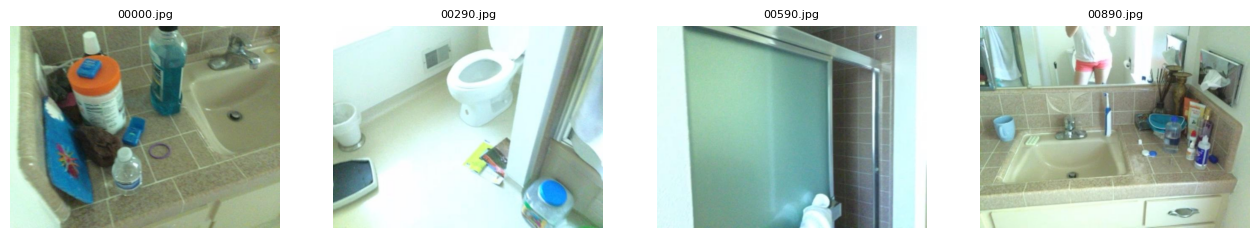

scene0631_01   (122 frames)
In this bedroom scene, there is a single dresser and two cabinets. The cabinets are positioned in front of the dresser, while the dresser is situated behind the cabinets. The room exudes a sense of functionality and organization, with the dresser serving as a storage space for personal belongings. The cabinets, on the other hand, offer additional storage options. The overall style of the room suggests a practical and efficient use of space, providing comfort and convenience to its occupants.


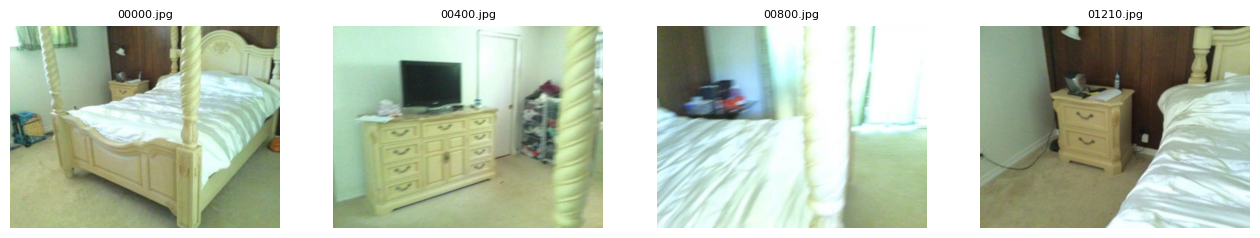

scene0631_02   (132 frames)
In the bedroom, two alarm clocks and a single lamp adorn the space. The room is further embellished with two curtains. The objects in this room suggest a functional and comfortable environment for rest and relaxation. The alarm clocks serve to wake the sleeper, while the lamp provides illumination. The curtains add a touch of elegance and privacy. The arrangement of these objects implies a well-organized and cozy bedroom setting.


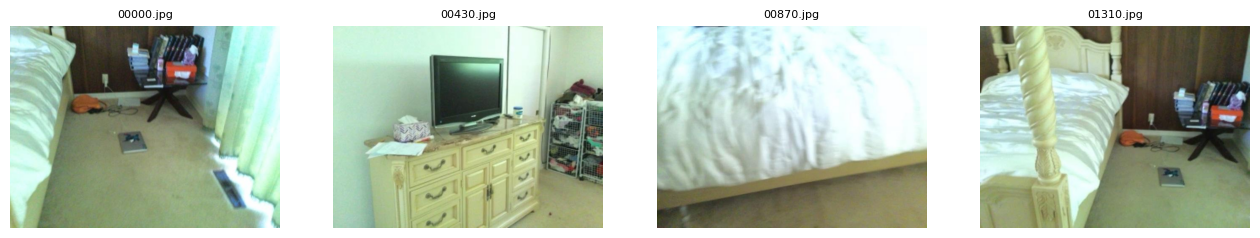

In [4]:
rng = random.Random(SEED)
SPACE = None
multi = sorted(k for k, v in spaces.items() if len(v) > 1)
space = SPACE or rng.choice(multi)
print("space:", space, "->", spaces[space])
show_scans(spaces[space], lambda s: scannet_cap[s]["captions"][0], frames_for_scannet)


## 3. 3RScan: environment grouping from `3RScan.json`

The scripts under `dataset/` never downloaded this metadata file. The cell below looks for it
locally and tries to fetch it once (needs network). If that fails, download it manually from
`http://campar.in.tum.de/public_datasets/3RScan/3RScan.json` to the path printed.

In [5]:
META_CANDIDATES = [THREERSCAN_ROOT / "3RScan.json", ROOT / "source_data/3rscan_meta/3RScan.json"]
META_URL = "http://campar.in.tum.de/public_datasets/3RScan/3RScan.json"

meta_path = next((p for p in META_CANDIDATES if p.exists()), None)
if meta_path is None:
    import urllib.request
    meta_path = META_CANDIDATES[0]
    try:
        urllib.request.urlretrieve(META_URL, meta_path)
        print("downloaded", meta_path)
    except Exception as e:
        print("could not fetch 3RScan.json:", e)
        print("download it manually to", meta_path)
        meta_path = None
else:
    print("found", meta_path)

if meta_path is not None:
    meta = json.load(open(meta_path))
    print(type(meta), len(meta))
    print(json.dumps(meta[0], indent=1)[:1000])


downloaded /glob/g01-cache/pf/Yushuo/vjepa201/source_data/3rscan/3RScan.json
<class 'list'> 478
{
 "ambiguity": [],
 "reference": "00d42bed-778d-2ac6-86a7-0e0e5f5f5660",
 "scans": [
  {
   "reference": "00d42bef-778d-2ac6-848a-008ef6c19ad6",
   "rigid": [
    40
   ]
  }
 ],
 "type": "test"
}


The next cell assumes each entry looks like `{"reference": <uuid>, "scans": [{"reference": <uuid>, ...}, ...]}`.
If it raises a `KeyError`, compare against the structure printed above and adjust.

In [6]:
env_of = {}
for entry in meta:
    ref = entry["reference"]
    env_of[ref] = ref
    for s in entry.get("scans", []):
        env_of[s["reference"]] = ref

covered = sum(1 for sid in leo_3rscan if sid in env_of)
print(f"3RScan captioned scans found in metadata: {covered}/{len(leo_3rscan)}")

envs = defaultdict(list)
for sid in sorted(leo_3rscan):
    envs[env_of.get(sid, sid)].append(sid)

per_env = Counter(len(v) for v in envs.values())
print(f"{len(leo_3rscan)} scans -> {len(envs)} distinct environments")
print("scans per environment:", dict(sorted(per_env.items())))


3RScan captioned scans found in metadata: 1381/1381
1381 scans -> 478 distinct environments
scans per environment: {1: 46, 2: 177, 3: 144, 4: 61, 5: 28, 6: 8, 7: 5, 8: 6, 10: 1, 12: 2}


## 4. 3RScan: rescans of one environment, side by side

3RScan rescans are recorded at different times, so small objects may have moved, appeared or
disappeared between them. Compare the captions and frames for what actually differs.

environment: 5630cfc9-12bf-2860-84ed-5bb189f0e94e -> ['10b17946-3938-2467-8bd9-0cc6be6dff91', '5630cfc9-12bf-2860-84ed-5bb189f0e94e', 'bf9a3daa-45a5-2e80-8162-9bf768132559', 'c92fb592-f771-2064-8446-c2605c0202e9', 'd7d40d66-7a5d-2b36-941c-8c8d61e4e0ab', 'd7d40d68-7a5d-2b36-9671-6d4fcab1912a']
10b17946-3938-2467-8bd9-0cc6be6dff91   (211 frames)
In this scene, there is a white rectangular window attached to a white wall. The window is made of glass and is closed. There is also a white tall shelf attached to the same wall, close to a pipe. The shelf is messy. A brown rectangular cardboard box is standing on the floor, to the right of a brown cupboard and to the left of a white shelf. There is a white door close to a radiator. A shiny wooden mirror is to the right of the radiator. There are also several bags and a garbage bin lying on the messy white floor. The bags are flexible, and the garbage bin is rigid. The scene appears to be a r


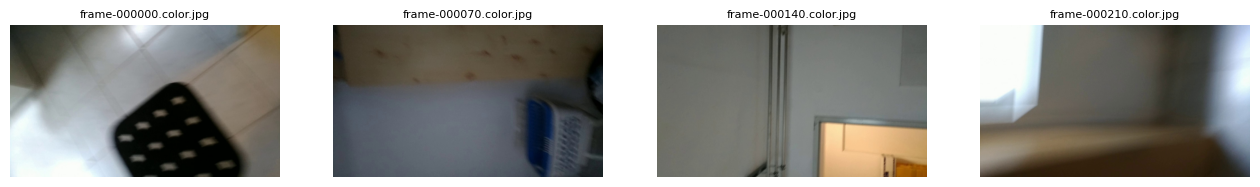

5630cfc9-12bf-2860-84ed-5bb189f0e94e   (467 frames)
In this scene, there is a narrow ironing board and a white washing basket. There are also flexible bags lying on the floor, with one in front and to the right of another bag. A white chair is on the left of the bags, in front of a cupboard and a shelf. The chair is also behind a box and to the right of a washing machine. There is a white garbage bin to the left of the chair and a brown box to the left of the bin. The floor is messy and made of ceramic tiles. The walls are flat and white. There is a mirror attached to one of the walls, and a pipe attached to the ceiling. The sink is white and e


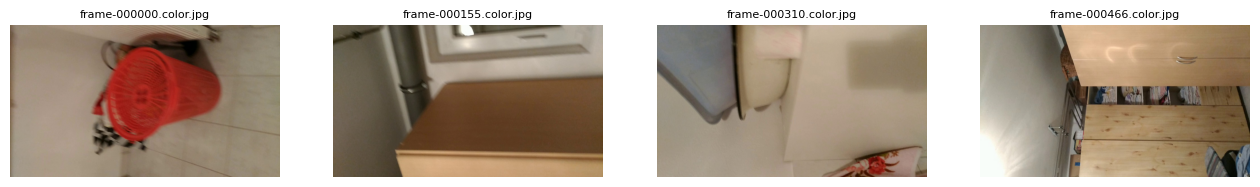

bf9a3daa-45a5-2e80-8162-9bf768132559   (187 frames)
In this scene, there is a narrow and rigid ironing board. The room has white rectangular windows that are attached to the walls. There is a white tall door hanging on the wall, next to a shiny wooden mirror. The floor is made of white ceramic tiles and is messy. There are brown cardboard boxes and a blue rectangular box standing on the floor. A white chair is placed next to a small white cupboard, and there is a messy white shelf next to it. A washing machine and a garbage bin are also present. There are flexible bags lying on the floor, close to the bags are the cupboard, chair, and boxes. Th


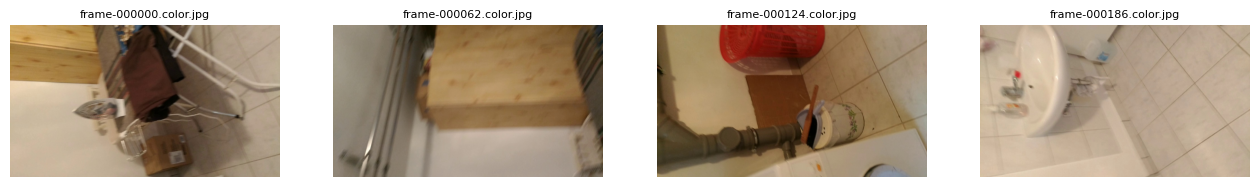

c92fb592-f771-2064-8446-c2605c0202e9   (225 frames)
In this scene, there is a narrow and rigid ironing board. The room has a tall rectangular white window made of glass. There are flexible bags placed close to each other, some to the right and left of other objects. There is a brown rectangular cardboard box and a white chair. The messy white shelf is to the left of the window. There is a garbage bin to the left of the bags. The room also has a washing machine, a cupboard, and a sink. The room has a white door hanging on the wall. The room seems to be organized and functional, with objects arranged for cleaning and storage purposes.


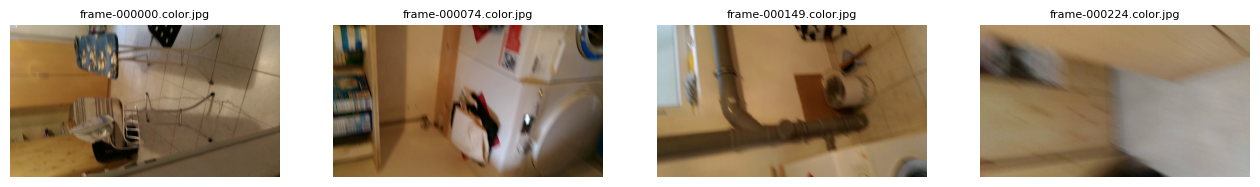

d7d40d66-7a5d-2b36-941c-8c8d61e4e0ab   (363 frames)
In this scene, there is a room with a white flat floor, white walls, and a closed white rectangular window attached to the wall. There are two bags, one lying on the floor and the other behind it. The bags are flexible and have no specific attributes. There is also a cardboard box standing on the floor, to the left of the bags. The box is brown and rectangular. A messy white rectangular shelf is to the right of the bags, and a small white cupboard is to the left of the bags. The cupboard is small and the shelf is messy. There is a blue rectangular box in front of the bags, and a garbage bin to


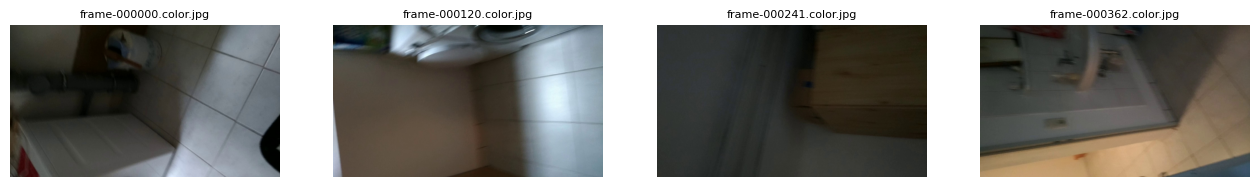

d7d40d68-7a5d-2b36-9671-6d4fcab1912a   (302 frames)
In this scene, there is a brown rectangular box made of cardboard on the floor. A white wall is attached to the floor, and there are windows attached to the wall. There is a white chair standing on the floor, to the left of a white shelf. The shelf is in front of a small white cupboard, and there is a mirror attached to the wall behind the chair. A white washing machine is to the left of the chair. There is also a white garbage bin and a bag close by. The floor is messy and made of ceramic. The scene suggests that this is a messy room, possibly a laundry room, with various objects placed hapha


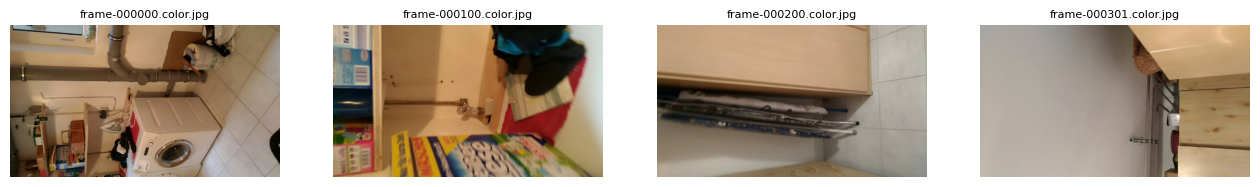

In [7]:
rng = random.Random(SEED)
multi3 = sorted(k for k, v in envs.items() if len(v) > 1)
env = rng.choice(multi3)
print("environment:", env, "->", envs[env])
show_scans(envs[env], lambda s: leo_3rscan[s][0]["response"], frames_for_3rscan)


## 5. Summary and a reusable group id

In [8]:
def group_id(scan_id):
    if scan_id.startswith("scene"):
        return "scannet/" + scannet_space_id(scan_id)
    return "3rscan/" + env_of.get(scan_id, scan_id)


print(f"ScanNet: {len(scannet_cap)} scans, {len(spaces)} spaces")
print(f"3RScan:  {len(leo_3rscan)} scans, {len(envs)} environments")
print(f"total:   {len(scannet_cap) + len(leo_3rscan)} scans, {len(spaces) + len(envs)} distinct spaces")
print()
for sid in [next(iter(scannet_cap)), next(iter(leo_3rscan))]:
    print(sid, "->", group_id(sid))


ScanNet: 1510 scans, 706 spaces
3RScan:  1381 scans, 478 environments
total:   2891 scans, 1184 distinct spaces

scene0442_00 -> scannet/scene0442
1776ad80-4db7-2333-8b18-f02ef42f3569 -> 3rscan/1776ad7e-4db7-2333-89e1-66854e82170c
